# 00 — Data Gap Diagnostics

**Author** : Anwesha Singh — CSE, Manipal University Jaipur

---

## Purpose

Run this notebook **once before training** to understand the recording gaps  
in your dataset and verify the gap filter is configured correctly.

### Background

The previous pipeline suffered from a critical bug: `energy.shift(-k)` moves  
by **row index**, not by **time**.  When rows `t` and `t+k` are separated by a  
recording gap of several days, the computed `energy_delta_k` equals the total  
energy consumed across the entire gap rather than the intended k-second increment.

This caused:
- Training MSE ≈ 0.007 but validation MSE ≈ 1672 (240,000× difference)
- All predictions clustering near zero
- Scatter plot with three clusters at (−400, 0), (0, 0), (+400, 0)

The new `load_and_prepare_data` function automatically filters these rows.  
This notebook shows you exactly how many rows are affected and where the gaps are.


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)

from core.config        import DATA_PATH, FORECAST_HORIZONS, GAP_TOLERANCE_FACTOR
from core.preprocessing import diagnose_gaps, load_and_prepare_data

sns.set(style="whitegrid")
print(f"Data file : {DATA_PATH}")
print(f"Gap tolerance factor : {GAP_TOLERANCE_FACTOR}")

Data file : C:\Users\AnweshaSingh\anaconda_projects\pipelinev5\data\raw\2agosto -dic 2021.csv
Gap tolerance factor : 2.0


---
## 1 · Timestamp sampling interval distribution

In [2]:
# Load timestamps only (fast)
df_ts = pd.read_csv(DATA_PATH, usecols=["fecha_servidor"],
                    on_bad_lines="skip", engine="python")
df_ts.rename(columns={"fecha_servidor": "server_timestamp"}, inplace=True)
df_ts["server_timestamp"] = pd.to_datetime(df_ts["server_timestamp"])
df_ts = df_ts.sort_values("server_timestamp").reset_index(drop=True)
df_ts.drop_duplicates(inplace=True)
df_ts.reset_index(drop=True, inplace=True)

dt_seconds = df_ts["server_timestamp"].diff().dt.total_seconds().dropna()

print("Sampling interval statistics (seconds):")
print(dt_seconds.describe().to_string())
print(f"\nDate range: {df_ts['server_timestamp'].min()}  →  {df_ts['server_timestamp'].max()}")
print(f"Total rows: {len(df_ts):,}")

Sampling interval statistics (seconds):
count    2.848408e+06
mean     3.666882e+00
std      3.385672e+03
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      5.683031e+06

Date range: 2021-08-05 10:58:36  →  2021-12-04 08:18:12
Total rows: 2,848,409


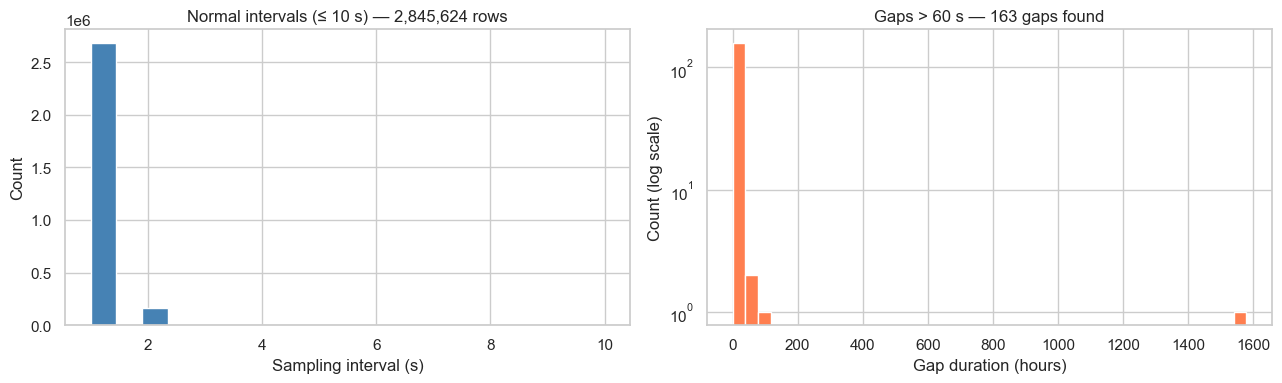


Gaps > 1 hour : 20
Gaps > 1 day  : 8
Gaps > 1 week : 1


In [4]:
# Distribution of sampling intervals (capped at 10 s to see normal behaviour)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: normal range
dt_normal = dt_seconds[dt_seconds <= 10]
axes[0].hist(dt_normal, bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Sampling interval (s)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Normal intervals (≤ 10 s) — {len(dt_normal):,} rows")

# Right: gap sizes (> 60 s) on log scale
dt_gaps = dt_seconds[dt_seconds > 60]
if len(dt_gaps) > 0:
    axes[1].hist(dt_gaps / 3600, bins=40, color="coral", edgecolor="white", log=True)
    axes[1].set_xlabel("Gap duration (hours)")
    axes[1].set_ylabel("Count (log scale)")
    axes[1].set_title(f"Gaps > 60 s — {len(dt_gaps):,} gaps found")
else:
    axes[1].text(0.5, 0.5, "No gaps > 60 s found",
                 ha="center", va="center", transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "results", "analysis",
                         "gap_distribution.png"), dpi=150)
plt.show(); plt.close()

print(f"\nGaps > 1 hour : {(dt_seconds > 3600).sum():,}")
print(f"Gaps > 1 day  : {(dt_seconds > 86400).sum():,}")
print(f"Gaps > 1 week : {(dt_seconds > 604800).sum():,}")

---
## 2 · Gap filter impact across all horizons

In [5]:
summary_rows = []

for k in FORECAST_HORIZONS:
    ts_future       = df_ts["server_timestamp"].shift(-k)
    elapsed         = (ts_future - df_ts["server_timestamp"]).dt.total_seconds()
    max_allowed     = GAP_TOLERANCE_FACTOR * k
    corrupted_mask  = elapsed.isna() | (elapsed > max_allowed)
    n_corrupted     = int(corrupted_mask.sum())
    n_total         = len(df_ts)

    summary_rows.append({
        "k (s)"            : k,
        "max_allowed (s)"  : max_allowed,
        "corrupted rows"   : n_corrupted,
        "clean rows"       : n_total - n_corrupted,
        "% corrupted"      : round(100 * n_corrupted / n_total, 2),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

 k (s)  max_allowed (s)  corrupted rows  clean rows  % corrupted
     1              2.0            6235     2842174         0.22
    60            120.0           21357     2827052         0.75
   300            600.0           23865     2824544         0.84
   900           1800.0           32639     2815770         1.15
  1800           3600.0           44976     2803433         1.58


---
## 3 · Detailed gap report for a specific horizon

In [6]:
# Change this to any horizon you want to inspect
INSPECT_HORIZON = 60

gap_df = diagnose_gaps(DATA_PATH, k=INSPECT_HORIZON, gap_factor=GAP_TOLERANCE_FACTOR)


Gap diagnostic  (k = 60 s, tolerance = 2.0x = 120 s)
  Total rows        :  2,848,409
  Corrupted targets :     21,357  (0.75 %)
  Clean targets     :  2,827,052  (99.25 %)

  Top gaps (duration > 120 s):
    2021-11-24 15:52:41      5,683,031 s  (  1578.6 h)
    2021-09-01 10:46:00        416,663 s  (   115.7 h)
    2021-09-18 00:09:02        271,919 s  (    75.5 h)
    2021-08-22 19:07:20        169,629 s  (    47.1 h)
    2021-09-11 03:17:50        139,762 s  (    38.8 h)
    2021-11-29 09:41:13        132,360 s  (    36.8 h)
    2021-08-12 07:00:53        115,373 s  (    32.0 h)
    2021-09-05 00:52:12        102,612 s  (    28.5 h)
    2021-12-01 10:59:16         86,381 s  (    24.0 h)
    2021-12-02 13:15:09         82,345 s  (    22.9 h)


---
## 4 · Target distribution BEFORE vs AFTER the gap filter

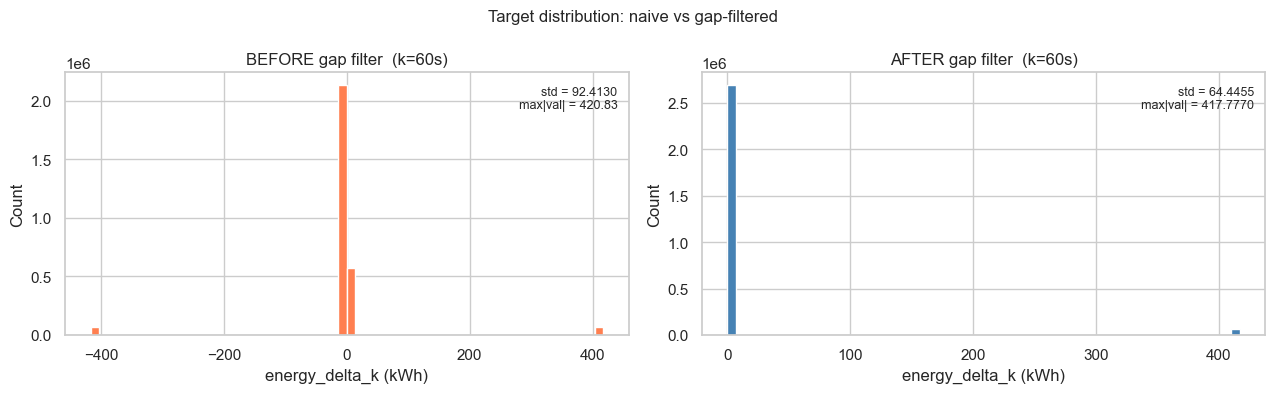


Naive  : 2,848,349 rows | std=92.412987 | max|x|=420.83
Filtered: 2,759,529 rows | std=64.445488 | max|x|=417.777000
Rows removed by filter: 88,820


In [7]:
# Load a sample of raw data to compare distributions
SAMPLE_K = 60

df_raw = pd.read_csv(DATA_PATH, on_bad_lines="skip", engine="python")
df_raw.rename(columns={"fecha_servidor": "server_timestamp",
                        "energia": "energy"}, inplace=True)
df_raw["server_timestamp"] = pd.to_datetime(df_raw["server_timestamp"])
df_raw = df_raw.sort_values("server_timestamp").reset_index(drop=True)
df_raw.drop_duplicates(subset=["server_timestamp"], inplace=True)
df_raw.reset_index(drop=True, inplace=True)

# Naive target (old pipeline — row-based shift, no gap check)
naive_delta = df_raw["energy"].shift(-SAMPLE_K) - df_raw["energy"]

# Gap-filtered target (new pipeline)
ts_future       = df_raw["server_timestamp"].shift(-SAMPLE_K)
elapsed         = (ts_future - df_raw["server_timestamp"]).dt.total_seconds()
max_allowed     = GAP_TOLERANCE_FACTOR * SAMPLE_K
valid_mask      = (elapsed.notna()) & (elapsed <= max_allowed) & (naive_delta >= 0)
filtered_delta  = naive_delta[valid_mask]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Naive distribution
naive_plot = naive_delta.dropna()
p1, p99 = naive_plot.quantile(0.01), naive_plot.quantile(0.99)
axes[0].hist(naive_plot.clip(p1, p99), bins=60, color="coral", edgecolor="white")
axes[0].set_title(f"BEFORE gap filter  (k={SAMPLE_K}s)")
axes[0].set_xlabel("energy_delta_k (kWh)")
axes[0].set_ylabel("Count")
axes[0].annotate(f"std = {naive_plot.std():.4f}\nmax|val| = {naive_plot.abs().max():.2f}",
                  xy=(0.98, 0.95), xycoords="axes fraction",
                  ha="right", va="top", fontsize=9)

# Filtered distribution
p1f, p99f = filtered_delta.quantile(0.01), filtered_delta.quantile(0.99)
axes[1].hist(filtered_delta.clip(p1f, p99f), bins=60, color="steelblue", edgecolor="white")
axes[1].set_title(f"AFTER gap filter  (k={SAMPLE_K}s)")
axes[1].set_xlabel("energy_delta_k (kWh)")
axes[1].set_ylabel("Count")
axes[1].annotate(f"std = {filtered_delta.std():.4f}\nmax|val| = {filtered_delta.abs().max():.4f}",
                  xy=(0.98, 0.95), xycoords="axes fraction",
                  ha="right", va="top", fontsize=9)

plt.suptitle("Target distribution: naive vs gap-filtered", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "results", "analysis",
                         f"target_distribution_k{SAMPLE_K}.png"), dpi=150)
plt.show(); plt.close()

print(f"\nNaive  : {len(naive_plot):,} rows | std={naive_plot.std():.6f} | max|x|={naive_plot.abs().max():.2f}")
print(f"Filtered: {len(filtered_delta):,} rows | std={filtered_delta.std():.6f} | max|x|={filtered_delta.abs().max():.6f}")
print(f"Rows removed by filter: {len(naive_plot) - len(filtered_delta):,}")

---
## 5 · Verify the full pipeline runs cleanly

In [8]:
# Run the full cleaned pipeline for k=60 to confirm preprocessing summary
print("Running load_and_prepare_data with gap filter enabled ...")
df_clean = load_and_prepare_data(DATA_PATH, k=60, verbose=True)

print("\nFirst 5 rows of target column:")
print(df_clean[["server_timestamp", "energy", "energy_delta_k"]].head())

# Sanity checks
assert df_clean["energy_delta_k"].isna().sum() == 0, "NaN targets remain!"
assert (df_clean["energy_delta_k"] < 0).sum() == 0, "Negative targets remain!"
print("\nAll sanity checks passed.")

Running load_and_prepare_data with gap filter enabled ...

  Preprocessing summary  (k = 60 s, tolerance = 2.0x)
  Rows in raw CSV          :  3,178,051
  Gap-corrupted targets    :     10,454  (elapsed > 120 s)
  Counter-reset targets    :    152,859  (delta_E < 0)
  Dropped for NaN          :    163,314
  Removed by Z-score       :    336,462  (features only)
  Final usable rows        :  2,678,196

  Target  energy_delta_k  statistics:
    mean  =     6.639824 kWh
    std   =    52.195938 kWh
    min   =     0.000000 kWh
    max   =   417.777000 kWh
    |max| =   417.777000 kWh


First 5 rows of target column:
     server_timestamp  energy  energy_delta_k
0 2021-08-05 12:44:49  171.89            0.01
1 2021-08-05 12:44:50  171.89            0.01
2 2021-08-05 12:44:51  171.89            0.01
3 2021-08-05 12:44:52  171.89            0.01
4 2021-08-05 12:44:53  171.89            0.01

All sanity checks passed.


---
## 6 · Adjust GAP_TOLERANCE_FACTOR if needed

If the diagnostics above show that too many rows are being removed,  
or that extreme values are still present after filtering,  
adjust `GAP_TOLERANCE_FACTOR` in `core/config.py`.

| Factor | Behaviour |
|---|---|
| 1.5 | Very strict — removes rows where elapsed > 1.5× k |
| 2.0 | Recommended — tolerates brief dropouts |
| 3.0 | Lenient — allows larger irregular gaps to pass |

After changing the factor, re-run this notebook to see the updated impact.